# Diabetes_Prediction

In [1]:
# Importing Libraries

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
import plotly.graph_objects as go 


import warnings 
warnings.filterwarnings("ignore")

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all' 

# choose a matplotlib style option 
plt.style.use("seaborn-v0_8-bright") 

# choose a seaborn style option 
sns.set_style("darkgrid") 

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate # K' - fold Cross Validation 


from collections import Counter
from imblearn.over_sampling import SMOTE, BorderlineSMOTE

import optuna
from optuna.samplers import GridSampler, RandomSampler

In [4]:
diabet_df=pd.read_csv(r"C:/Users/91912/Desktop/ML/Datasets/Dataset of Diabetes .csv")

In [5]:
# copy of the dataset 
df=diabet_df.copy()

### Simple EDA

In [11]:
# getting the columns of the dataset 

df.columns

Index(['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG',
       'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='object')

In [13]:
# Getting complete Information of dataset 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB


In [15]:
# Checking for duplicates

df.duplicated().sum()

0

In [17]:
# Here in this data, we have ID and No_Pation which are unique features values and they are not important for the data 
# so we drop this features or columns 

df.drop( ["ID","No_Pation"], axis=1, inplace=True)

In [19]:
# Checking for duplicates

df.duplicated().sum()

169

In [21]:
# Dropping the Duplicates

df.drop_duplicates(inplace=True )

In [23]:
# Extracting the top 5 rows 

df.head() 

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
4,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
5,F,45,2.3,24,4.0,2.9,1.0,1.0,1.5,0.4,21.0,N
6,F,50,2.0,50,4.0,3.6,1.3,0.9,2.1,0.6,24.0,N


In [25]:
# Checking the shape of dataset 

df.shape

(831, 12)

In [27]:
# Summary of the Numerical columns 

df.describe()

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,831.000000,831.000000,831.000000,831.000000,831.000000,831.000000,831.000000,831.000000,831.000000,831.000000
mean,53.418773,5.183566,68.971119,8.332202,4.896053,2.395283,1.211974,2.591083,1.810710,29.487918
std,8.870302,3.070515,59.393210,2.607280,1.326116,1.453699,0.678072,1.129763,3.571375,5.006987
min,20.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,51.000000,3.630000,48.000000,6.500000,4.000000,1.500000,0.900000,1.700000,0.700000,26.000000
50%,55.000000,4.600000,59.000000,8.100000,4.800000,2.000000,1.100000,2.500000,1.000000,30.000000
75%,59.000000,5.700000,73.000000,10.200000,5.600000,3.000000,1.300000,3.300000,1.500000,33.000000
max,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


In [29]:
# Summary of the Categorical Columns 

df.describe(include=np.object_)  

,Gender,CLASS
count,831,831
unique,3,5
top,M,Y
freq,467,691


In [1]:
import os
os.getcwd()

'C:\\Users\\91912\\ML Projects'

### Identifying the Unique Values in Categorical Columns

In [33]:
# Checking for Unique values for categorical columns 

df['Gender'].unique()

# here we have to replace the values where the values are case sensitive 
df['Gender'] = df['Gender'].str.replace("f","F") 

# checking after replacing the values 
df['Gender'].unique()

array(['F', 'M', 'f'], dtype=object)

array(['F', 'M'], dtype=object)

In [35]:
# Checking for Unique values for categorical columns 

df['CLASS'].unique()

# here we have to replace the values where the values have spaces before or after. 
df['CLASS'] = df['CLASS'].str.strip()

# checking after replacing the values 
df['CLASS'].unique()

array(['N', 'N ', 'P', 'Y', 'Y '], dtype=object)

array(['N', 'P', 'Y'], dtype=object)

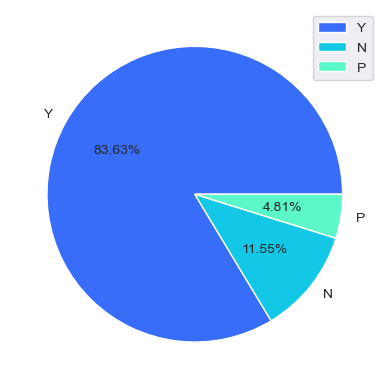

In [37]:
# Checking the Percentages of Values present in CLASS 

plt.pie(x=df['CLASS'].value_counts(), labels=df['CLASS'].value_counts().index, autopct="%.2f%%", colors=sns.color_palette("rainbow"))
plt.legend()
plt.show();

- Class-Y has 83.63% of the data which is used to result in Imbalance dataset
- Class-P and Class-N have 11.55% and 4.81% . 
- This Imbalance dataset leads to model bias which predicts 'Y' class with high accuracy but predicts less accuracy for 'P' and 'N' classes

In [40]:
# Checking the Skewness for the numerical values

df.skew(numeric_only=True)  

AGE     -0.813706
Urea     4.264092
Cr       8.168990
HbA1c    0.189050
Chol     0.579300
TG       2.302848
HDL      6.302161
LDL      1.004766
VLDL     5.690278
BMI      0.081198
dtype: float64

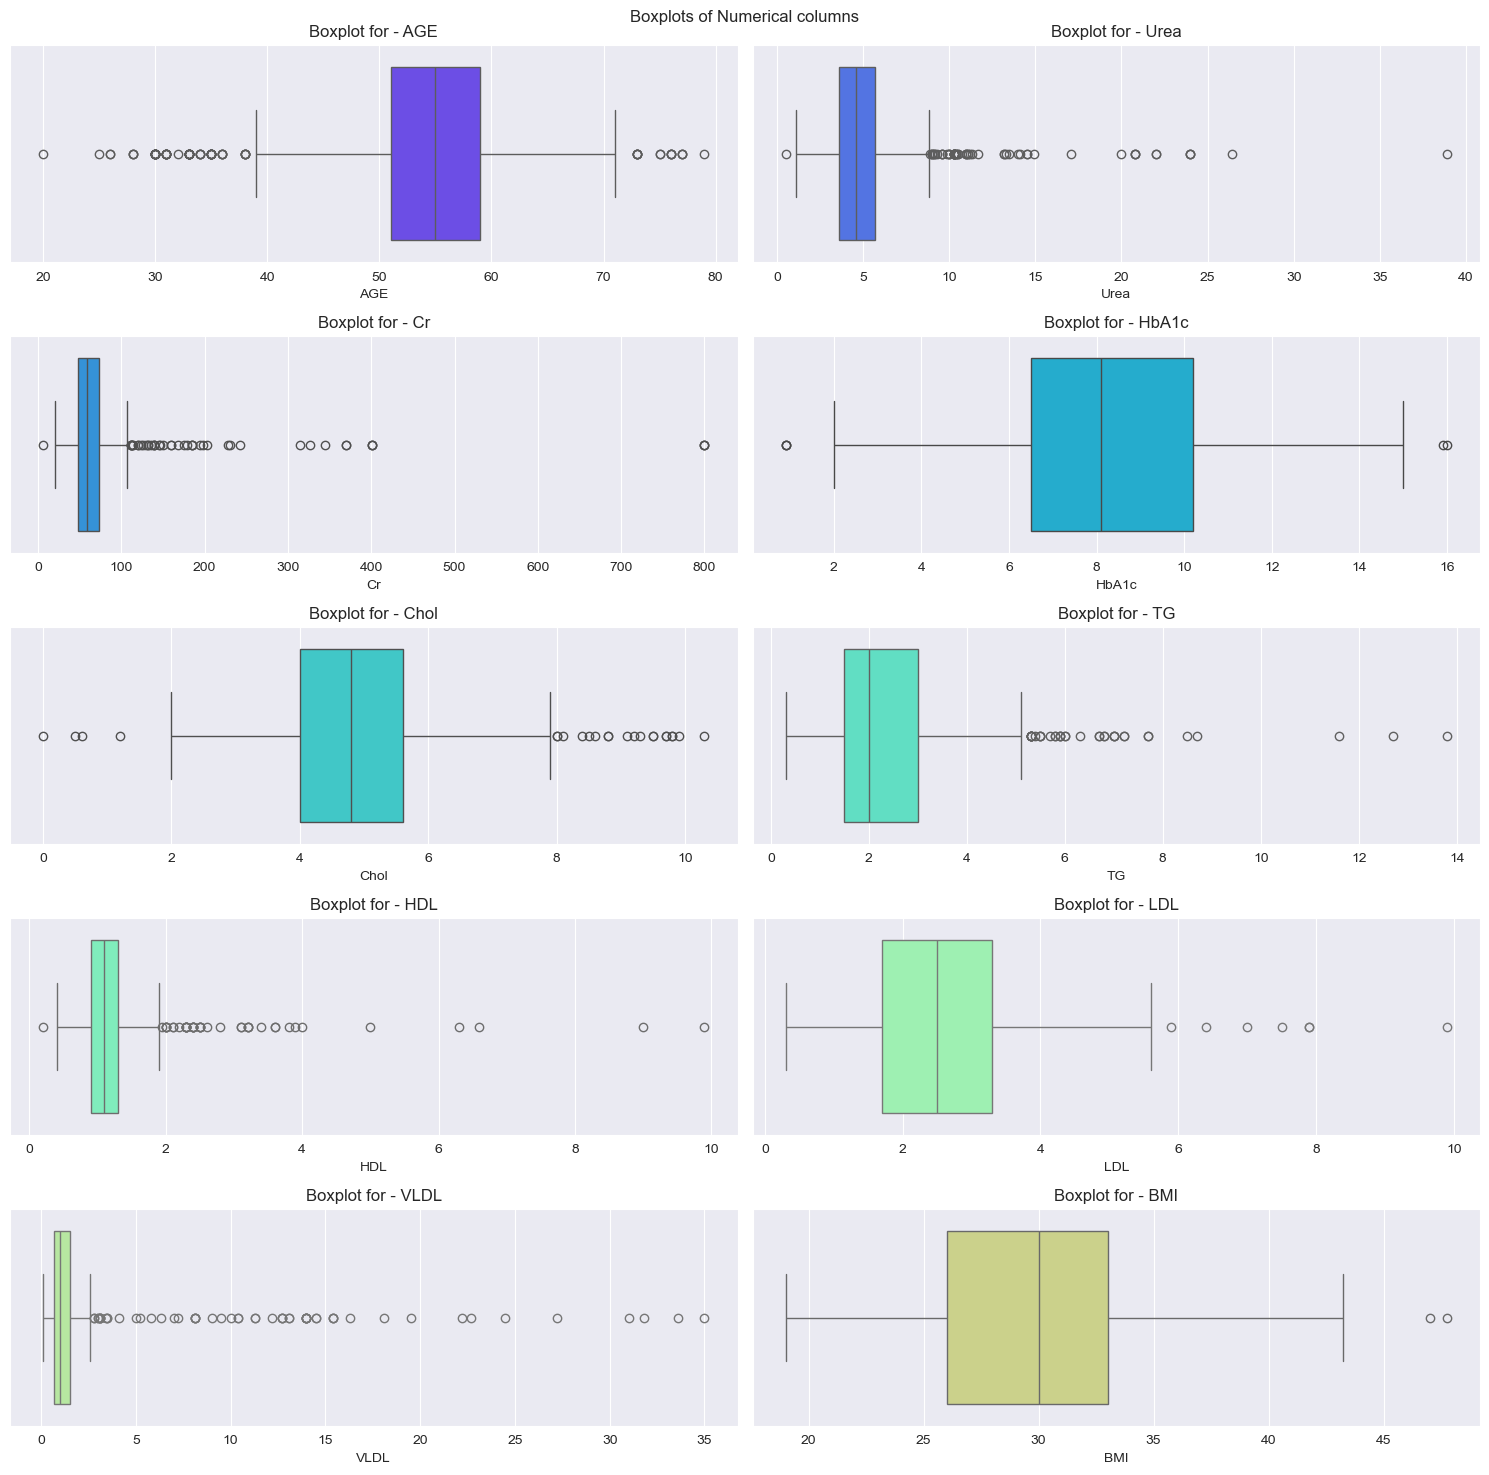

In [42]:
# gettting the numerical columns and ploting the boxplot of that columns 
num_cols=df.select_dtypes(include=["float", "int"]).columns

# Plot all box plots 
fig, axs = plt.subplots(nrows=5, ncols=2, figsize = (15,15))


pos = axs.flatten() 

for i in range(len(num_cols)): 
    sns.boxplot(data=df, x = df[num_cols[i]], ax = pos[i], color=sns.color_palette("rainbow", 14)[i])
    pos[i].set_title(f"Boxplot for - {num_cols[i]}")

plt.suptitle("Boxplots of Numerical columns")
plt.tight_layout()
plt.show();

#### IQR With Cap approch of Threshold values and Lower,Upper

In [44]:
# Normal Values of Male and Female 
#male_values={ "Urea":[2.86,8.57], "Cr":[65,120], "HbA1c":[5.7], "Chol":[5.18], "TG":[1.70], "HDL":[1.04], "LDL":[2.59,3.37], "VLDL":[0.06,0.33] } 
#female_values={"Urea":[2.14,7.50], "Cr":[52,92], "HbA1c":[5.7], "Chol":[5.18], "TG":[1.70], "HDL":[1.3], "LDL":[2.59,3.37], "VLDL":[0.06,0.33] }

# Threshold Values
#threshold_values={ "Urea":[1.8,17.8], "Cr":[27,265], "HbA1c":[3,15], "Chol":[2.6,10.4], "TG":[0.4,6.8], "HDL":[0.5,2.6], "LDL":[1.0,5.2], "VLDL":[0.06,0.66] } 

In [46]:
#def iqr_based_func(df, columns, threshold_values):
#
#    df1=df.copy()
#
#    for column in columns:     
#        q1,q3 = df1[column].quantile(q=[0.25,0.75]) 
#        iqr = q3-q1 
#        ub = round(q3+1.5*iqr, 1)
#        lb = round(q1-1.5*iqr, 1)
#       
#        df1.loc[(df1[column]<lb), column] =  lb 
#        df1.loc[(df1[column]>ub), column] =  ub 
#
#    return df1 

In [48]:

#outliers_columns=['Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL','VLDL']
#df_out=iqr_based_func(df, outliers_columns, threshold_values )
#df_out

In [50]:
def iqr_based_func(df, columns,):

    df1=df.copy()

    for column in columns:     
        q1,q3 = df1[column].quantile(q=[0.25,0.75]) 
        iqr = q3-q1 
        ub = round(q3+1.5*iqr, 1)
        lb = round(q1-1.5*iqr, 1)
       
        df1.loc[(df1[column]<lb), column] =  lb 
        df1.loc[(df1[column]>ub), column] =  ub 

    return df1 

In [52]:

outliers_columns=['Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL','VLDL']
df_out=iqr_based_func(df, outliers_columns, )
df_out

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50,4.7,46.0,4.9,4.2,0.9,1.9,1.4,0.5,24.0,N
1,M,26,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
4,M,33,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
5,F,45,2.3,24.0,4.0,2.9,1.0,1.0,1.5,0.4,21.0,N
6,F,50,2.0,50.0,4.0,3.6,1.3,0.9,2.1,0.6,24.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...
995,M,71,8.8,97.0,7.0,7.5,1.7,1.2,1.8,0.6,30.0,Y
996,M,31,3.0,60.0,12.3,4.1,2.2,0.7,2.4,2.7,37.2,Y
997,M,30,7.1,81.0,6.7,4.1,1.1,1.2,2.4,2.7,27.4,Y
998,M,38,5.8,59.0,6.7,5.3,2.0,1.6,2.9,2.7,40.5,Y


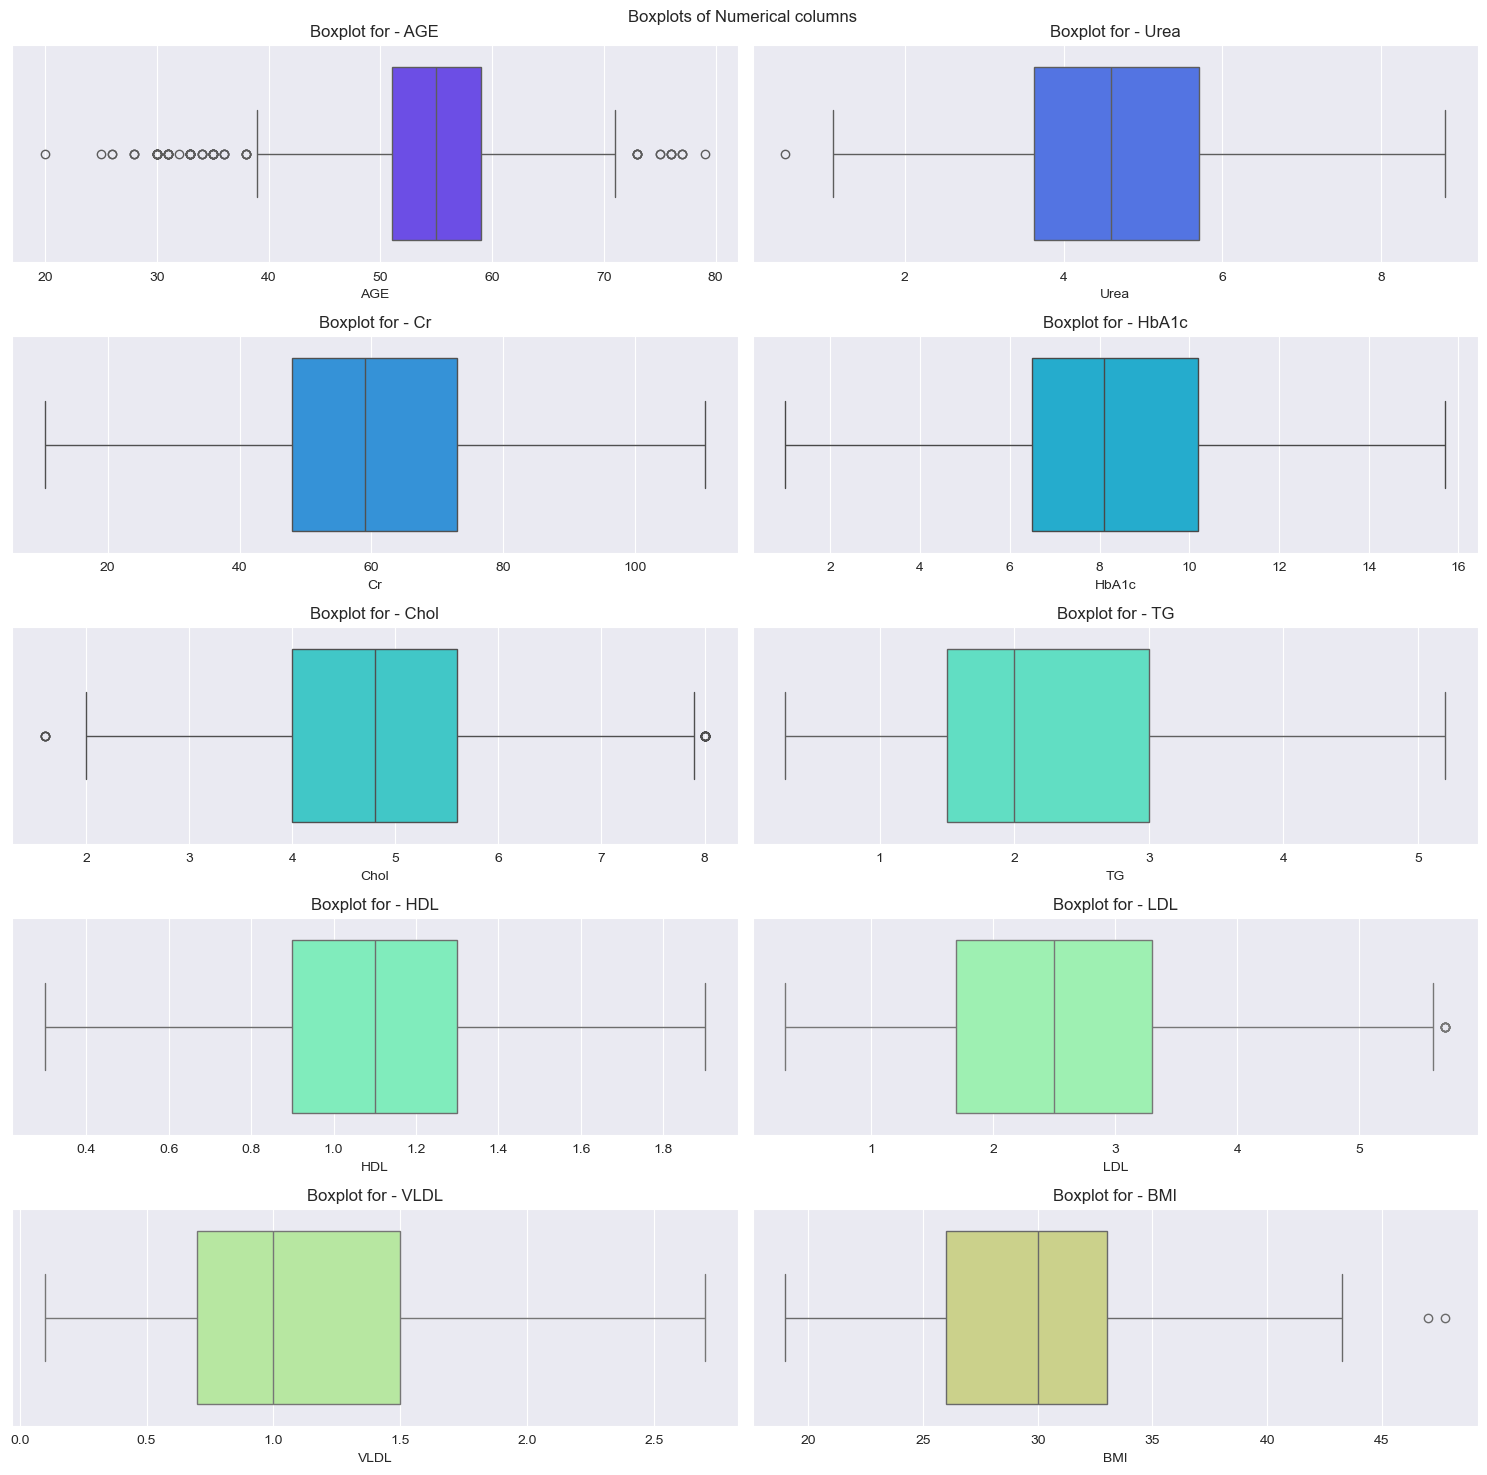

In [54]:
# gettting the numerical columns and ploting the boxplot of that columns 
num_cols=df_out.select_dtypes(include=["float", "int"]).columns

# Plot all box plots 
fig, axs = plt.subplots(nrows=5, ncols=2, figsize = (15,15))


pos = axs.flatten() 

for i in range(len(num_cols)): 
    sns.boxplot(data=df_out, x = df_out[num_cols[i]],ax = pos[i], color=sns.color_palette("rainbow", 14)[i])
    pos[i].set_title(f"Boxplot for - {num_cols[i]}")

plt.suptitle("Boxplots of Numerical columns")
plt.tight_layout()
plt.show();

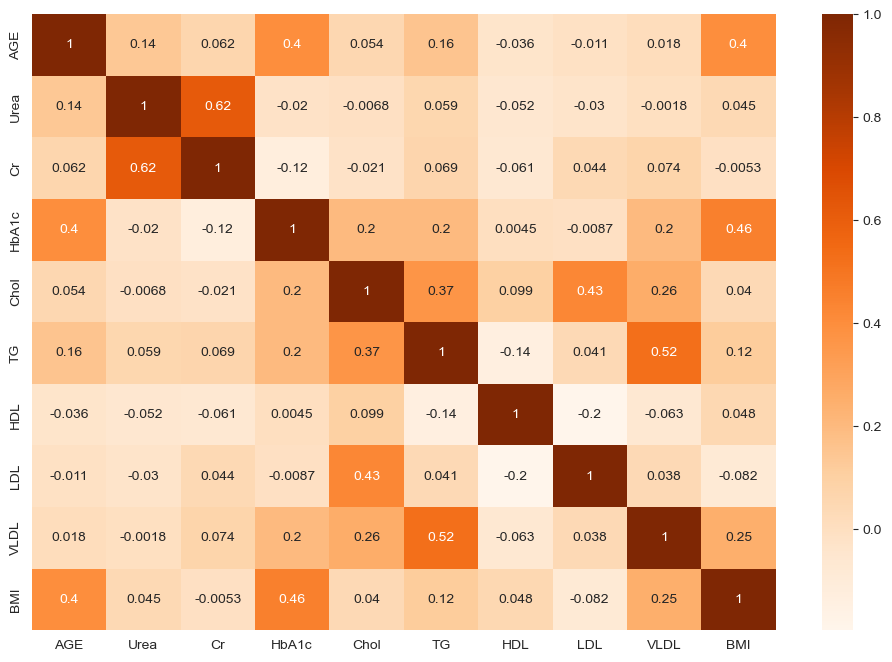

In [57]:
# Checking the Co-relation between Numerical Columns 
corr_mat=df_out.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_mat, annot=True,  cmap="Oranges")
plt.show();

### Splitting the dataset

In [60]:
feature_variables=df_out.iloc[:,:-1]
class_variables=df_out.iloc[:,-1]

In [249]:
x_train, x_test, y_train, y_test = train_test_split( feature_variables, class_variables, test_size=0.2, stratify=class_variables, random_state=123)

In [251]:
(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

((664, 11), (167, 11), (664,), (167,))

#### Encoding

In [255]:
ohe=OneHotEncoder(drop="first", sparse_output=False, dtype=int) 
x_train_gender=ohe.fit_transform( x_train[['Gender']])
x_train['Gender']=x_train_gender.reshape(x_train_gender.shape[0]) 

In [257]:
x_test_gender = ohe.transform(x_test[['Gender']])
x_test['Gender'] = x_test_gender.reshape(x_test.shape[0]) 

In [259]:
x_train

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
905,0,54,3.80,59.0,9.1,6.5,2.60,1.40,4.00,1.1,33.00
187,1,40,5.90,76.0,4.0,5.0,2.10,1.60,3.00,0.9,24.00
358,1,61,4.70,58.0,6.4,4.4,2.10,0.70,2.90,0.9,26.00
212,1,57,4.60,110.5,6.8,6.1,5.20,1.90,3.50,1.1,37.00
76,0,35,3.30,44.0,5.0,4.1,1.90,1.90,1.30,0.7,23.00
...,...,...,...,...,...,...,...,...,...,...,...
478,1,60,2.70,35.0,9.0,4.4,2.00,0.60,3.00,0.9,27.00
704,1,55,6.66,61.0,7.7,4.1,2.03,1.08,2.20,2.7,37.62
706,1,56,4.10,51.0,11.5,5.9,1.70,1.73,1.04,0.7,31.00
658,0,67,3.20,38.0,8.7,5.0,3.00,1.10,2.70,1.3,30.00


In [261]:
oe=OrdinalEncoder(categories=[["N","P","Y"]], dtype=int)
y_train_arr=oe.fit_transform(y_train.values.reshape(-1, 1))
y_train=y_train_arr.flatten()  
y_test_arr=oe.transform(y_test.values.reshape(-1, 1))
y_test=y_test_arr.flatten()
(y_train.shape, y_test.shape) 

((664,), (167,))

### Feature Scaling 

In [264]:
std=StandardScaler()
x_train_scaled=std.fit_transform(x_train)
x_test_scaled=std.transform(x_test) 

#### Balancing the Data using Over Sampling Techniques

In [269]:
from collections import Counter

Counter(y_train)

Counter({2: 555, 0: 77, 1: 32})

In [271]:
#from imblearn.over_sampling import SMOTE
#smote=SMOTE(random_state=123)
#x_train_sm,y_train_sm=smote.fit_resample(x_train_scaled,y_train)

In [273]:
#Counter(y_train_sm)

In [275]:
bsm = BorderlineSMOTE(random_state=4)
x_train_bsm, y_train_bsm = bsm.fit_resample(x_train_scaled,y_train)

In [277]:
Counter(y_train_bsm) 

Counter({2: 555, 0: 555, 1: 555})

In [279]:
x_train_bsm.shape, y_train_bsm.shape

((1665, 11), (1665,))

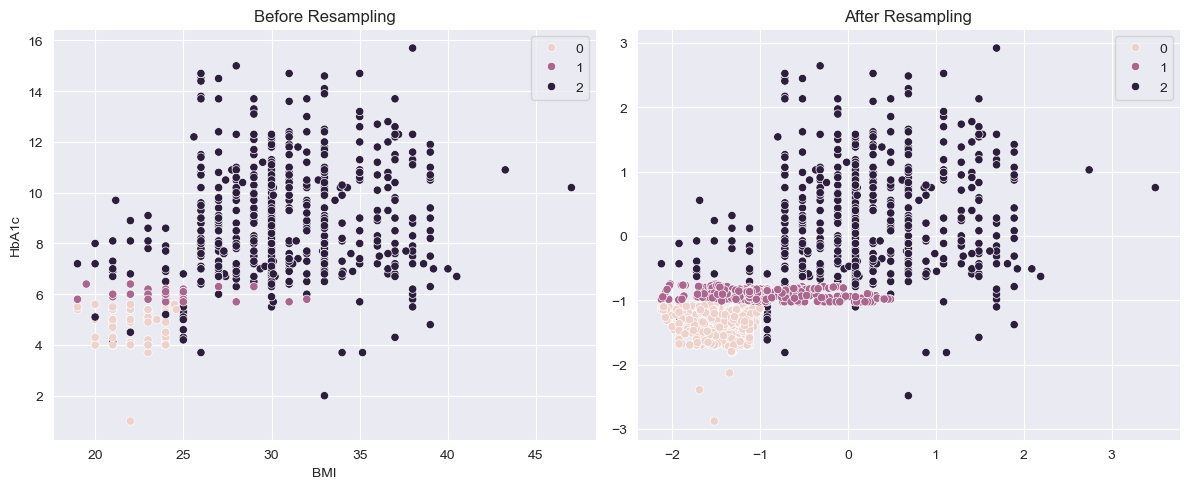

In [283]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Before Resampling")
sns.scatterplot(x=x_train['BMI'], y=x_train['HbA1c'], hue=y_train)

plt.subplot(1,2,2)
plt.title("After Resampling")
sns.scatterplot(x=x_train_bsm[:,10], y=x_train_bsm[:,4], hue=y_train_bsm)
plt.tight_layout()
plt.show(); 

#### HyperParameter Tuning

In [285]:
def objective(trial): 
    
    # define the hyper parameters with its range of values 
    k_value=trial.suggest_int("k", 1,30,2) 
    weight_value=trial.suggest_categorical("w",["uniform","distance"])

    # algorithm 
    knn=KNeighborsClassifier(n_neighbors=k_value, weights=weight_value) 

    # training by using k-fold cv 
    values=cross_validate( estimator=knn, X=x_train_bsm, y=y_train_bsm, cv=5, scoring="accuracy", return_train_score=True)
    cv_accuracy=values['test_score'].mean()
    train_accuracy=values['train_score'].mean() 

    #return any additional values  
    trial.set_user_attr("Train Accuracy", train_accuracy) 
    
    return cv_accuracy

## Grid Sampler

In [288]:
space={"k":range(1,30,2), "w":["uniform", "distance"]}

In [290]:
# Grid Sampler 

study=optuna.create_study(direction="maximize", sampler=GridSampler( search_space=space)) 

[I 2025-06-09 21:36:14,924] A new study created in memory with name: no-name-952c2e72-3874-488b-b21b-f87d7156de4a


In [292]:
study.optimize(objective)

[I 2025-06-09 21:36:15,569] Trial 0 finished with value: 0.9663663663663664 and parameters: {'k': 3, 'w': 'uniform'}. Best is trial 0 with value: 0.9663663663663664.
[I 2025-06-09 21:36:16,108] Trial 1 finished with value: 0.893093093093093 and parameters: {'k': 29, 'w': 'uniform'}. Best is trial 0 with value: 0.9663663663663664.
[I 2025-06-09 21:36:16,339] Trial 2 finished with value: 0.9417417417417416 and parameters: {'k': 13, 'w': 'distance'}. Best is trial 0 with value: 0.9663663663663664.
[I 2025-06-09 21:36:16,750] Trial 3 finished with value: 0.9381381381381381 and parameters: {'k': 11, 'w': 'uniform'}. Best is trial 0 with value: 0.9663663663663664.
[I 2025-06-09 21:36:17,281] Trial 4 finished with value: 0.8966966966966966 and parameters: {'k': 27, 'w': 'uniform'}. Best is trial 0 with value: 0.9663663663663664.
[I 2025-06-09 21:36:17,749] Trial 5 finished with value: 0.9021021021021021 and parameters: {'k': 25, 'w': 'uniform'}. Best is trial 0 with value: 0.9663663663663664.

In [293]:
study.trials_dataframe() 

,number,value,datetime_start,datetime_complete,duration,params_k,params_w,user_attrs_Train Accuracy,system_attrs_grid_id,system_attrs_search_space,state
0,0,0.966366,2025-06-09 21:36:15.228664,2025-06-09 21:36:15.569137,0 days 00:00:00.340473,3,uniform,0.977027,0,"{'k': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, ...",COMPLETE
1,1,0.893093,2025-06-09 21:36:15.569137,2025-06-09 21:36:16.108855,0 days 00:00:00.539718,29,uniform,0.903754,1,"{'k': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, ...",COMPLETE
2,2,0.941742,2025-06-09 21:36:16.108855,2025-06-09 21:36:16.339604,0 days 00:00:00.230749,13,distance,1.000000,2,"{'k': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, ...",COMPLETE
3,3,0.938138,2025-06-09 21:36:16.343298,2025-06-09 21:36:16.750432,0 days 00:00:00.407134,11,uniform,0.946246,3,"{'k': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, ...",COMPLETE
4,4,0.896697,2025-06-09 21:36:16.750432,2025-06-09 21:36:17.281533,0 days 00:00:00.531101,27,uniform,0.910961,4,"{'k': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, ...",COMPLETE
5,5,0.902102,2025-06-09 21:36:17.281533,2025-06-09 21:36:17.749177,0 days 00:00:00.467644,25,uniform,0.916817,5,"{'k': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, ...",COMPLETE
6,6,0.930330,2025-06-09 21:36:17.749177,2025-06-09 21:36:17.978042,0 days 00:00:00.228865,27,distance,1.000000,6,"{'k': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, ...",COMPLETE
7,7,0.945345,2025-06-09 21:36:17.979102,2025-06-09 21:36:18.202036,0 days 00:00:00.222934,11,distance,1.000000,7,"{'k': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, ...",COMPLETE
8,8,0.938138,2025-06-09 21:36:18.203877,2025-06-09 21:36:18.401542,0 days 00:00:00.197665,17,distance,1.000000,8,"{'k': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, ...",COMPLETE
9,9,0.909910,2025-06-09 21:36:18.404193,2025-06-09 21:36:19.043228,0 days 00:00:00.639035,23,uniform,0.924024,9,"{'k': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, ...",COMPLETE


In [294]:
study.best_params

{'k': 1, 'w': 'distance'}

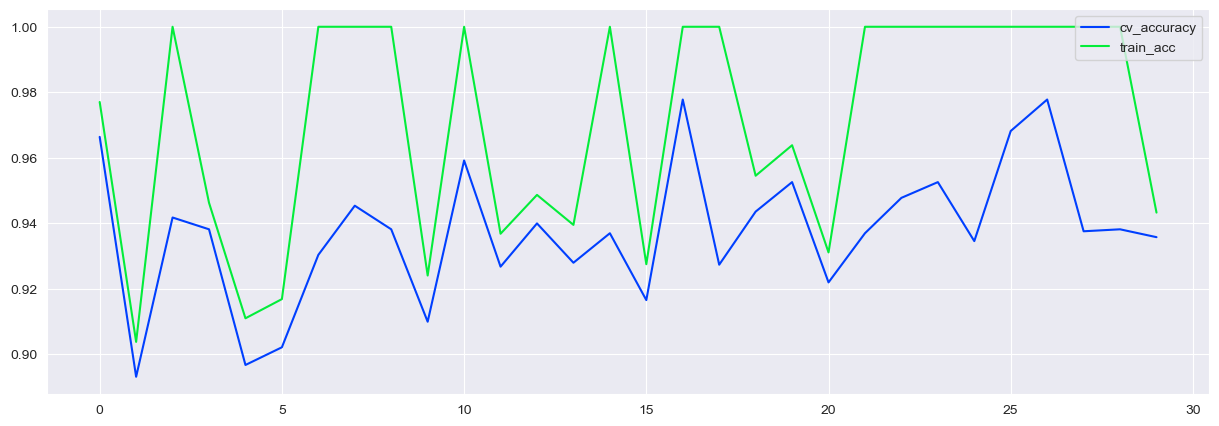

In [295]:
plt.figure(figsize=(15,5))
plt.plot(study.trials_dataframe()["number"],study.trials_dataframe()["value"],label="cv_accuracy")
plt.plot(study.trials_dataframe()["number"],study.trials_dataframe()["user_attrs_Train Accuracy"],label="train_acc")
plt.legend(loc='upper right')
plt.show();

In [296]:
study.best_value

0.9777777777777776

In [297]:
knn = KNeighborsClassifier(n_neighbors = 1, weights = 'distance')
model = knn.fit(x_train_bsm,y_train_bsm)
y_cv = model.predict(x_test_scaled)
accuracy_score(y_test,y_cv)

0.9161676646706587

## Random Sampler

In [112]:
study = optuna.create_study(direction="maximize", sampler=RandomSampler())

[I 2025-06-09 19:54:14,532] A new study created in memory with name: no-name-c36f9e98-982a-4a07-b140-3b1c1e15acba


In [113]:
study.optimize(objective, n_trials=100)

[I 2025-06-09 19:54:14,732] Trial 0 finished with value: 0.9381381381381381 and parameters: {'k': 17, 'w': 'distance'}. Best is trial 0 with value: 0.9381381381381381.
[I 2025-06-09 19:54:15,459] Trial 1 finished with value: 0.927927927927928 and parameters: {'k': 15, 'w': 'uniform'}. Best is trial 0 with value: 0.9381381381381381.
[I 2025-06-09 19:54:15,806] Trial 2 finished with value: 0.9663663663663664 and parameters: {'k': 3, 'w': 'uniform'}. Best is trial 2 with value: 0.9663663663663664.
[I 2025-06-09 19:54:16,248] Trial 3 finished with value: 0.9381381381381381 and parameters: {'k': 11, 'w': 'uniform'}. Best is trial 2 with value: 0.9663663663663664.
[I 2025-06-09 19:54:16,683] Trial 4 finished with value: 0.927927927927928 and parameters: {'k': 15, 'w': 'uniform'}. Best is trial 2 with value: 0.9663663663663664.
[I 2025-06-09 19:54:17,184] Trial 5 finished with value: 0.9777777777777776 and parameters: {'k': 1, 'w': 'uniform'}. Best is trial 5 with value: 0.9777777777777776.
[

In [114]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_k,params_w,user_attrs_Train Accuracy,state
0,0,0.938138,2025-06-09 19:54:14.537333,2025-06-09 19:54:14.730619,0 days 00:00:00.193286,17,distance,1.000000,COMPLETE
1,1,0.927928,2025-06-09 19:54:14.732432,2025-06-09 19:54:15.459839,0 days 00:00:00.727407,15,uniform,0.939489,COMPLETE
2,2,0.966366,2025-06-09 19:54:15.459839,2025-06-09 19:54:15.806529,0 days 00:00:00.346690,3,uniform,0.977027,COMPLETE
3,3,0.938138,2025-06-09 19:54:15.806529,2025-06-09 19:54:16.248362,0 days 00:00:00.441833,11,uniform,0.946246,COMPLETE
4,4,0.927928,2025-06-09 19:54:16.248362,2025-06-09 19:54:16.683117,0 days 00:00:00.434755,15,uniform,0.939489,COMPLETE
...,...,...,...,...,...,...,...,...,...
95,95,0.893093,2025-06-09 19:54:48.512365,2025-06-09 19:54:48.979008,0 days 00:00:00.466643,29,uniform,0.903754,COMPLETE
96,96,0.921922,2025-06-09 19:54:48.979008,2025-06-09 19:54:49.419026,0 days 00:00:00.440018,19,uniform,0.931081,COMPLETE
97,97,0.935736,2025-06-09 19:54:49.419026,2025-06-09 19:54:49.796554,0 days 00:00:00.377528,13,uniform,0.943243,COMPLETE
98,98,0.952553,2025-06-09 19:54:49.796554,2025-06-09 19:54:49.919699,0 days 00:00:00.123145,7,distance,1.000000,COMPLETE


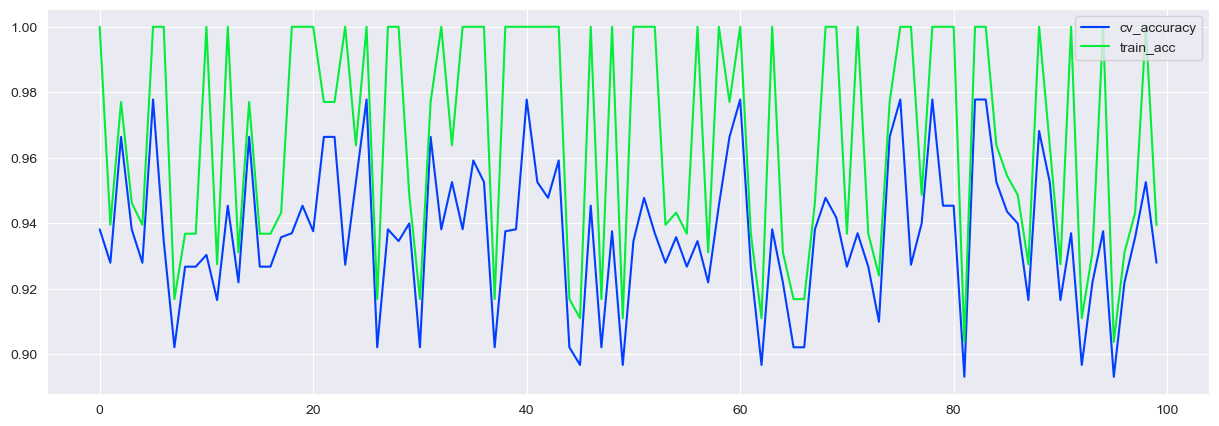

In [115]:
plt.figure(figsize=(15,5))
plt.plot(study.trials_dataframe()["number"],study.trials_dataframe()["value"],label="cv_accuracy")
plt.plot(study.trials_dataframe()["number"],study.trials_dataframe()["user_attrs_Train Accuracy"],label="train_acc")
plt.legend(loc='upper right') 
plt.show();

In [116]:
study.best_params 

{'k': 1, 'w': 'uniform'}

In [117]:
study.best_value

0.9777777777777776

In [118]:
knn = KNeighborsClassifier(n_neighbors = 1, weights = 'uniform')
model = knn.fit(x_train_bsm,y_train_bsm)
y_cv = model.predict(x_test_scaled)
accuracy_score(y_test,y_cv)

0.9161676646706587

#### HyperParamater with k-value, weights, algorithms

#### Grid Sampler

In [132]:
import optuna
from optuna.samplers import GridSampler, RandomSampler
def objective(trial): 
    
    # define the hyper parameters with its range of values 
    k_value=trial.suggest_int("k", 1,20,2) 
    weight_value=trial.suggest_categorical("w",["uniform","distance"])
    algo = trial.suggest_categorical('algo', ['auto', 'ball_tree', 'kd_tree', 'brute'])

    # algorithm 
    knn=KNeighborsClassifier(n_neighbors=k_value, weights=weight_value, algorithm=algo) 

    # training by using k-fold cv 
    values=cross_validate( estimator=knn, X=x_train_bsm, y=y_train_bsm, cv=5, scoring="accuracy", return_train_score=True)
    cv_accuracy=values['test_score'].mean()
    train_accuracy=values['train_score'].mean() 

    #return any additional values 
    trial.set_user_attr("Train Accuracy", train_accuracy)
    
    return cv_accuracy

In [134]:
# Grid Sampler 
space={"k":range(1,30,2), "w":["uniform", "distance"],  "algo": ["auto", "ball_tree", "kd_tree", "brute"]}
study=optuna.create_study(direction="maximize", sampler=GridSampler( search_space=space))

[I 2025-06-09 19:59:50,861] A new study created in memory with name: no-name-4ca777b2-6ea6-492f-a502-523d5bc12d28


In [136]:
study.optimize(objective)

[I 2025-06-09 19:59:51,995] Trial 0 finished with value: 0.9219219219219219 and parameters: {'k': 19, 'w': 'uniform', 'algo': 'ball_tree'}. Best is trial 0 with value: 0.9219219219219219.
[I 2025-06-09 19:59:52,305] Trial 1 finished with value: 0.9525525525525526 and parameters: {'k': 5, 'w': 'uniform', 'algo': 'brute'}. Best is trial 1 with value: 0.9525525525525526.
[I 2025-06-09 19:59:52,356] Trial 2 finished with value: 0.9591591591591593 and parameters: {'k': 5, 'w': 'distance', 'algo': 'brute'}. Best is trial 2 with value: 0.9591591591591593.
[I 2025-06-09 19:59:52,833] Trial 3 finished with value: 0.93993993993994 and parameters: {'k': 9, 'w': 'uniform', 'algo': 'auto'}. Best is trial 2 with value: 0.9591591591591593.
[I 2025-06-09 19:59:52,921] Trial 4 finished with value: 0.9525525525525526 and parameters: {'k': 7, 'w': 'distance', 'algo': 'brute'}. Best is trial 2 with value: 0.9591591591591593.
[I 2025-06-09 19:59:53,391] Trial 5 finished with value: 0.9099099099099099 and p

In [137]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_algo,params_k,params_w,user_attrs_Train Accuracy,system_attrs_grid_id,system_attrs_search_space,state
0,0,0.921922,2025-06-09 19:59:51.491543,2025-06-09 19:59:51.995699,0 days 00:00:00.504156,ball_tree,19,uniform,0.931081,0,"{'algo': ['auto', 'ball_tree', 'kd_tree', 'bru...",COMPLETE
1,1,0.952553,2025-06-09 19:59:51.997705,2025-06-09 19:59:52.305015,0 days 00:00:00.307310,brute,5,uniform,0.963814,1,"{'algo': ['auto', 'ball_tree', 'kd_tree', 'bru...",COMPLETE
2,2,0.959159,2025-06-09 19:59:52.305015,2025-06-09 19:59:52.356103,0 days 00:00:00.051088,brute,5,distance,1.000000,2,"{'algo': ['auto', 'ball_tree', 'kd_tree', 'bru...",COMPLETE
3,3,0.939940,2025-06-09 19:59:52.361583,2025-06-09 19:59:52.833847,0 days 00:00:00.472264,auto,9,uniform,0.948649,3,"{'algo': ['auto', 'ball_tree', 'kd_tree', 'bru...",COMPLETE
4,4,0.952553,2025-06-09 19:59:52.833847,2025-06-09 19:59:52.921905,0 days 00:00:00.088058,brute,7,distance,1.000000,4,"{'algo': ['auto', 'ball_tree', 'kd_tree', 'bru...",COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...
115,115,0.952553,2025-06-09 20:00:23.569630,2025-06-09 20:00:23.703014,0 days 00:00:00.133384,kd_tree,7,distance,1.000000,115,"{'algo': ['auto', 'ball_tree', 'kd_tree', 'bru...",COMPLETE
116,116,0.952553,2025-06-09 20:00:23.704784,2025-06-09 20:00:24.116086,0 days 00:00:00.411302,kd_tree,5,uniform,0.963814,116,"{'algo': ['auto', 'ball_tree', 'kd_tree', 'bru...",COMPLETE
117,117,0.930330,2025-06-09 20:00:24.116086,2025-06-09 20:00:24.239090,0 days 00:00:00.123004,brute,27,distance,1.000000,117,"{'algo': ['auto', 'ball_tree', 'kd_tree', 'bru...",COMPLETE
118,118,0.938138,2025-06-09 20:00:24.239090,2025-06-09 20:00:24.453335,0 days 00:00:00.214245,ball_tree,17,distance,1.000000,118,"{'algo': ['auto', 'ball_tree', 'kd_tree', 'bru...",COMPLETE


In [138]:
study.best_value

0.9777777777777776

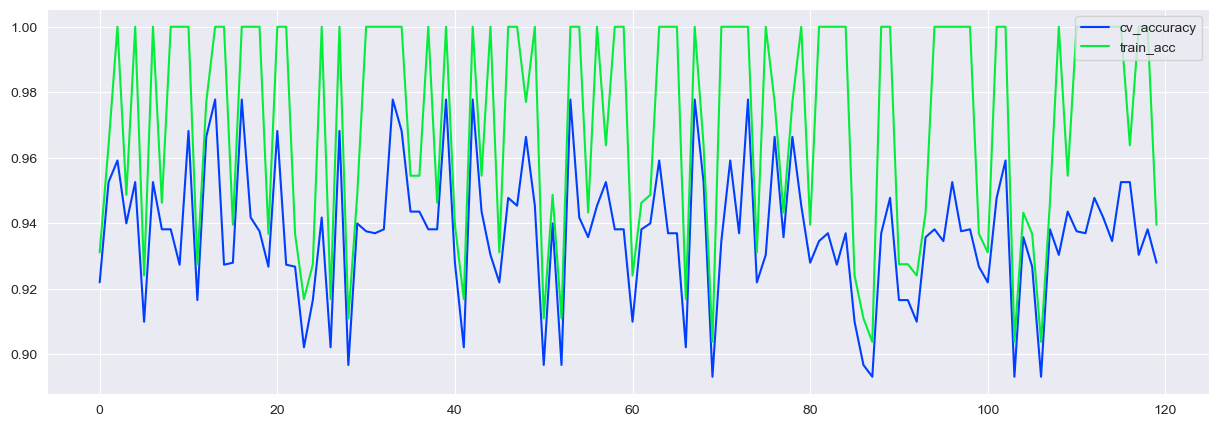

In [139]:
plt.figure(figsize=(15,5))
plt.plot(study.trials_dataframe()["number"],study.trials_dataframe()["value"],label="cv_accuracy")
plt.plot(study.trials_dataframe()["number"],study.trials_dataframe()["user_attrs_Train Accuracy"],label="train_acc")
plt.legend(loc='upper right')
plt.show();

In [140]:
study.best_params

{'k': 1, 'w': 'uniform', 'algo': 'kd_tree'}

In [141]:
knn = KNeighborsClassifier(n_neighbors = 1, weights = 'uniform', algorithm="kd_tree")
model = knn.fit(x_train_bsm,y_train_bsm)
y_cv = model.predict(x_test_scaled)
accuracy_score(y_test,y_cv)

0.9161676646706587

#### Random Sampler

In [144]:
study = optuna.create_study(direction="maximize", sampler=RandomSampler())

[I 2025-06-09 20:00:25,287] A new study created in memory with name: no-name-3fcc8174-5591-4251-bd3c-4a7d1efd6a56


In [145]:
study.optimize(objective, n_trials=100)

[I 2025-06-09 20:00:25,536] Trial 0 finished with value: 0.9477477477477478 and parameters: {'k': 9, 'w': 'distance', 'algo': 'auto'}. Best is trial 0 with value: 0.9477477477477478.
[I 2025-06-09 20:00:25,612] Trial 1 finished with value: 0.9525525525525526 and parameters: {'k': 5, 'w': 'uniform', 'algo': 'brute'}. Best is trial 1 with value: 0.9525525525525526.
[I 2025-06-09 20:00:25,664] Trial 2 finished with value: 0.9525525525525526 and parameters: {'k': 5, 'w': 'uniform', 'algo': 'brute'}. Best is trial 1 with value: 0.9525525525525526.
[I 2025-06-09 20:00:25,887] Trial 3 finished with value: 0.9381381381381381 and parameters: {'k': 17, 'w': 'distance', 'algo': 'kd_tree'}. Best is trial 1 with value: 0.9525525525525526.
[I 2025-06-09 20:00:26,086] Trial 4 finished with value: 0.9591591591591593 and parameters: {'k': 5, 'w': 'distance', 'algo': 'ball_tree'}. Best is trial 4 with value: 0.9591591591591593.
[I 2025-06-09 20:00:26,275] Trial 5 finished with value: 0.9417417417417416 

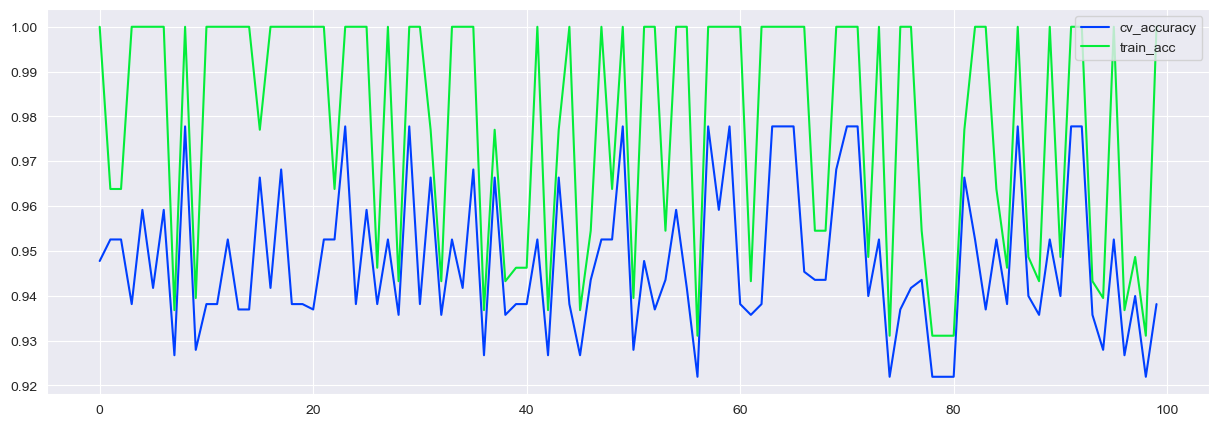

In [146]:
plt.figure(figsize=(15,5))
plt.plot(study.trials_dataframe()["number"],study.trials_dataframe()["value"],label="cv_accuracy")
plt.plot(study.trials_dataframe()["number"],study.trials_dataframe()["user_attrs_Train Accuracy"],label="train_acc")
plt.legend(loc='upper right')
plt.show();

In [147]:
study.best_params

{'k': 1, 'w': 'distance', 'algo': 'brute'}

In [148]:
knn = KNeighborsClassifier(n_neighbors = 1, weights = 'uniform', algorithm="brute")
model = knn.fit(x_train_bsm,y_train_bsm)
y_cv = model.predict(x_test_scaled)
accuracy_score(y_test,y_cv)

0.9161676646706587

In [172]:
import pickle 

In [174]:
with open("Standard.pkl","wb") as f:
    pickle.dump(std, f )

with open("OneHot.pkl","wb") as f:
    pickle.dump(ohe, f) 

with open("Ordinal.pkl","wb") as f:
    pickle.dump(oe, f) 

with open("KNN.pkl","wb") as f:
    pickle.dump(knn, f) 

